# Задание 10

## Задание 10.1

In [26]:
import numpy as np

import os
import sys

PI2 = 2 * np.pi

module_dir = os.path.join(os.getcwd(), "..")
sys.path.insert(0, module_dir)

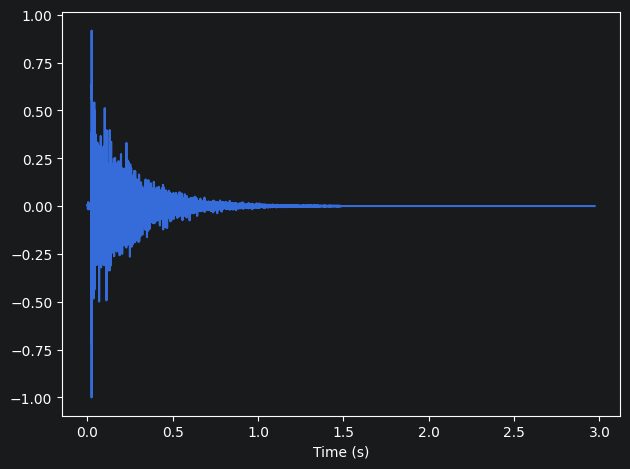

In [27]:
from thinkdsp import read_wave, decorate

response = read_wave('180960__kleeb__gunshot.wav')

start = 0.12
response = response.segment(start=start)
response.shift(-start)

response.truncate(2**16)
response.zero_pad(2**17)

response.normalize()
response.plot()
decorate(xlabel='Time (s)')

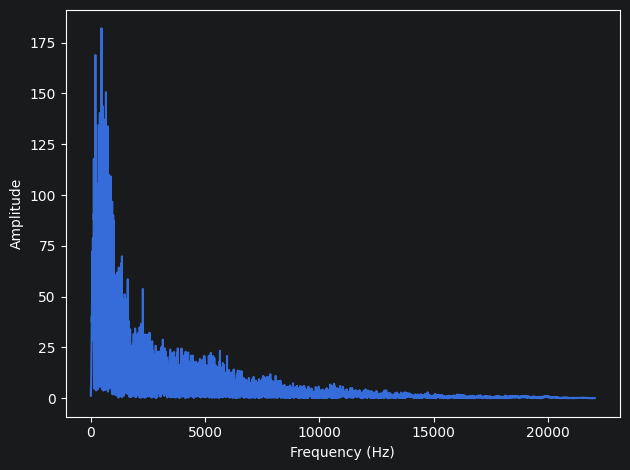

In [28]:
transfer = response.make_spectrum()
transfer.plot()
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

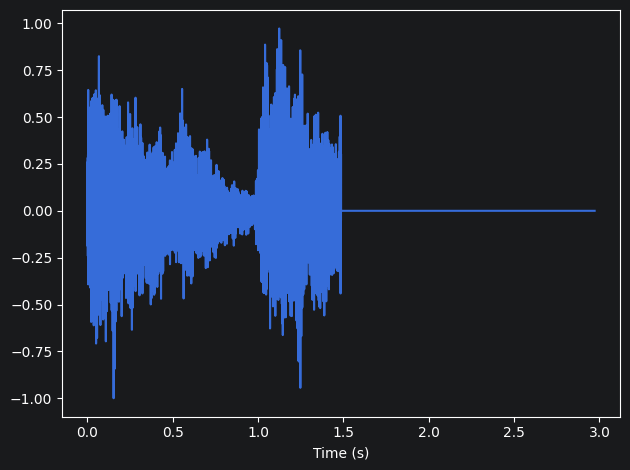

In [29]:
trumpet = read_wave('170255__dublie__trumpet.wav')

start = 0.11
trumpet = trumpet.segment(start=start)
trumpet.shift(-start)

trumpet.truncate(2 ** 16)
trumpet.zero_pad(2 ** 17)

trumpet.normalize()
trumpet.plot()
decorate(xlabel='Time (s)')

In [30]:
spectrum = trumpet.make_spectrum()

In [31]:
output = (spectrum * transfer).make_wave()
output.normalize()

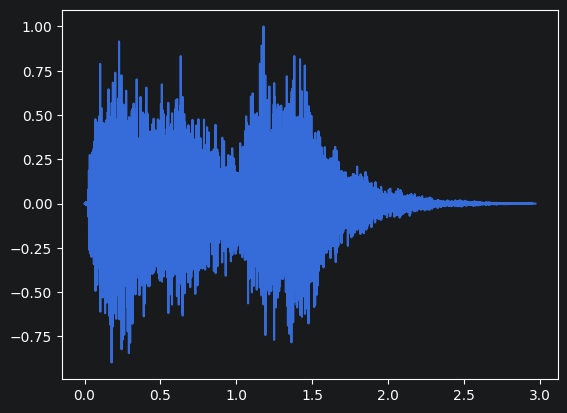

In [32]:
output.plot()

In [33]:
output.make_audio()

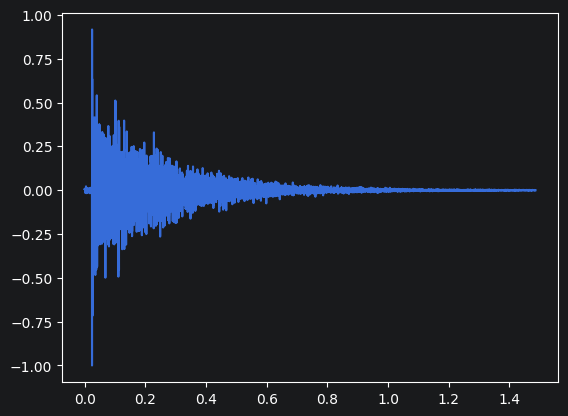

In [34]:
response.truncate(2**16)
response.plot()

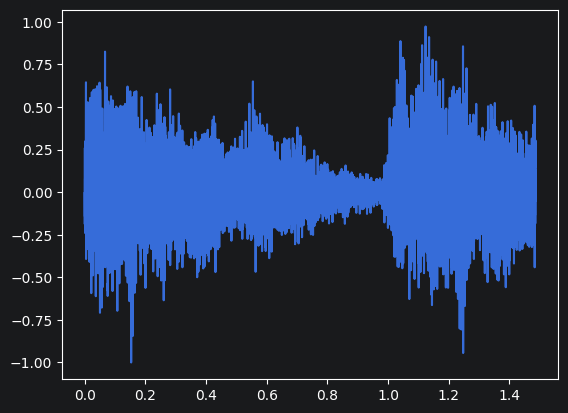

In [35]:
trumpet.truncate(2 ** 16)
trumpet.plot()

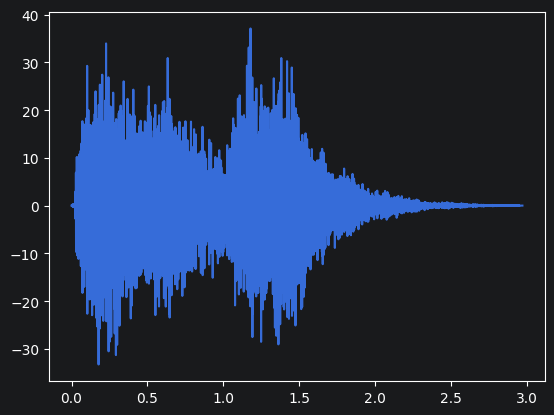

In [36]:
output2 = trumpet.convolve(response)
output2.plot()

In [37]:
output2.make_audio()

In [38]:
len(output), len(output2)

(131072, 131071)

np.float64(1.9539925233402755e-14)

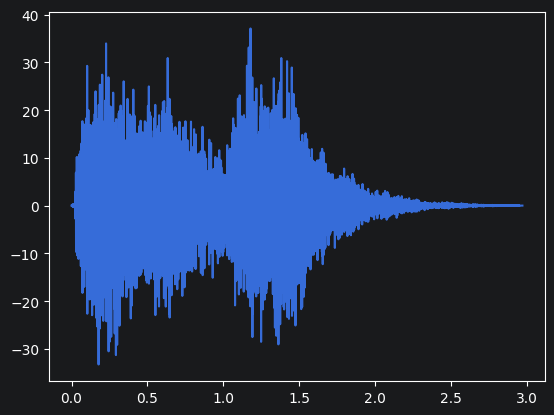

In [39]:
from thinkdsp import Wave

import scipy.signal
ys = scipy.signal.fftconvolve(trumpet.ys, response.ys)
output3 = Wave(ys, framerate=trumpet.framerate)

output3.plot()
output3.make_audio()
output2.max_diff(output3)

## Задание 10.2

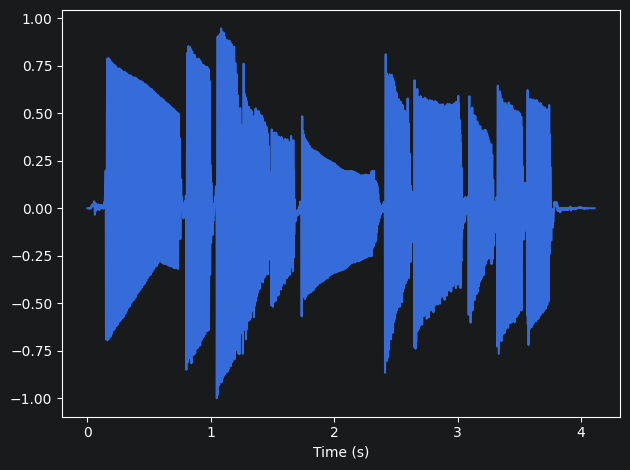

In [40]:
response = read_wave('328878__tzurkan__guitar-phrase-tzu.wav')

start = 0
duration = 5
response = response.segment(duration=duration)
response.shift(-start)

response.normalize()
response.plot()
decorate(xlabel='Time (s)')

In [41]:
response.make_audio()

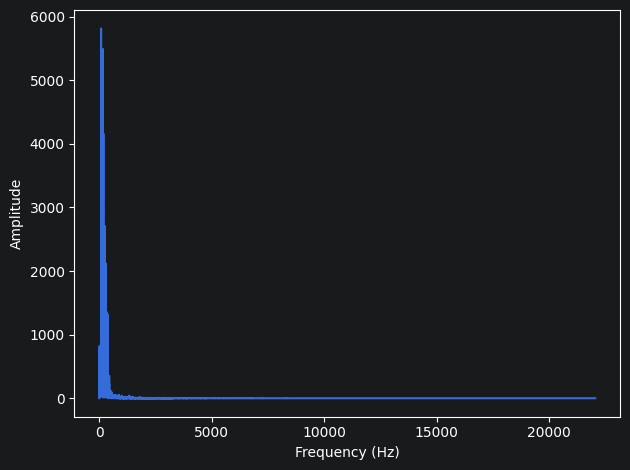

In [42]:
transfer = response.make_spectrum()
transfer.plot()
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

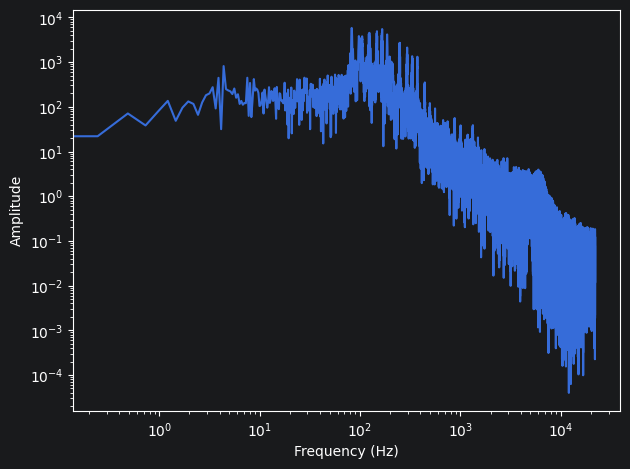

In [43]:
transfer.plot()
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude', xscale='log', yscale='log')

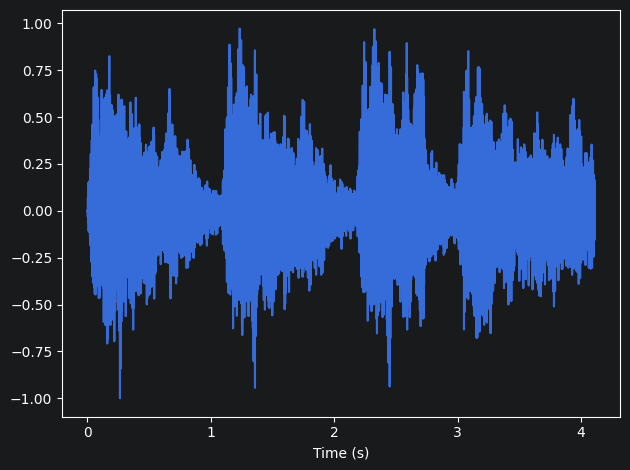

In [44]:
wave = read_wave('170255__dublie__trumpet.wav')

start = 0.0
wave = wave.segment(start=start)
wave.shift(-start)

wave.truncate(len(response))
wave.normalize()
wave.plot()
decorate(xlabel='Time (s)')

In [45]:
wave.make_audio()

spectrum = wave.make_spectrum()

len(spectrum.hs), len(transfer.hs)

spectrum.fs


array([0.00000000e+00, 2.43313030e-01, 4.86626059e-01, ...,
       2.20495134e+04, 2.20497567e+04, 2.20500000e+04], shape=(90625,))

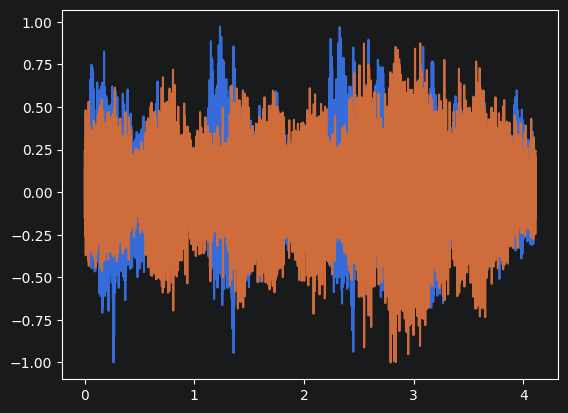

In [46]:
output = (spectrum * transfer).make_wave()
output.normalize()

wave.plot()
output.plot()


In [47]:

output.make_audio()


In [48]:
convolved2 = wave.convolve(response)
convolved2.normalize()
convolved2.make_audio()